In [1]:
import matplotlib.pyplot as plt
import pandas as pd

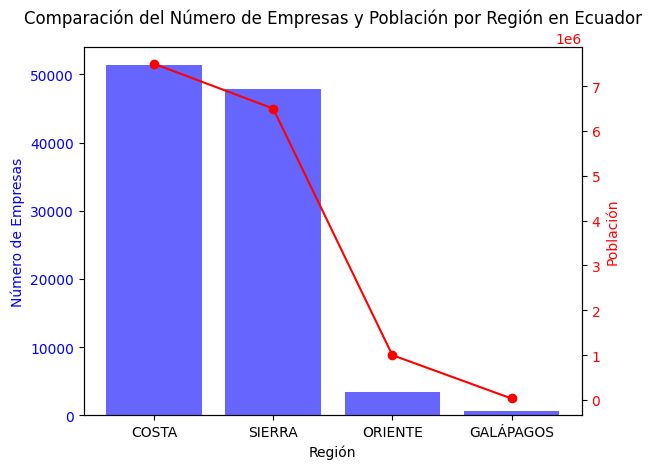

In [2]:


# Datos
data = {
    'Región': ['COSTA', 'SIERRA', 'ORIENTE', 'GALÁPAGOS'],
    'Empresas': [51437, 47893, 3351, 659],
    'Población': [7500000, 6500000, 1000000, 33042]
}

# Crear DataFrame
df = pd.DataFrame(data)

# Crear gráfica
fig, ax1 = plt.subplots()

# Gráfica de barras para el número de empresas
ax1.bar(df['Región'], df['Empresas'], color='b', alpha=0.6, label='Empresas')
ax1.set_xlabel('Región')
ax1.set_ylabel('Número de Empresas', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Crear un segundo eje y para la población
ax2 = ax1.twinx()
ax2.plot(df['Región'], df['Población'], color='r', marker='o', label='Población')
ax2.set_ylabel('Población', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Título y leyenda
plt.title('Comparación del Número de Empresas y Población por Región en Ecuador')
fig.tight_layout()
plt.show()


In [ ]:
from bokeh.io import output_file, show
from bokeh.plotting import figure
from bokeh.transform import cumsum
from bokeh.palettes import Category20c
import pandas as pd
from math import pi

# Suponiendo que `processed_inec` es tu DataFrame
data = processed_inec['unidad_legal_tipo'].value_counts().reset_index()
data.columns = ['unidad_legal_tipo', 'counts']
data['angle'] = data['counts']/data['counts'].sum() * 2*pi
data['color'] = Category20c[len(data)]

p = figure(plot_height=350, title="Distribución de Tipos de Unidad Legal", toolbar_location=None,
           tools="hover", tooltips="@unidad_legal_tipo: @counts", x_range=(-0.5, 1.0))

p.wedge(x=0, y=1, radius=0.4,
        start_angle=cumsum('angle', include_zero=True), end_angle=cumsum('angle'),
        line_color="white", fill_color='color', legend_field='unidad_legal_tipo', source=data)

p.axis.axis_label = None
p.axis.visible = False
p.grid.grid_line_color = None

output_file("pie_chart.html")
show(p)
